<a href="https://colab.research.google.com/github/karunrajcseai-hue/karunraj/blob/main/karun%20exp%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 263ms/step - accuracy: 0.5451 - loss: 0.6889 - val_accuracy: 0.6295 - val_loss: 0.6849
Epoch 2/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.6460 - loss: 0.6817 - val_accuracy: 0.6690 - val_loss: 0.6772
Epoch 3/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.6764 - loss: 0.6729 - val_accuracy: 0.6824 - val_loss: 0.6664
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6825 - loss: 0.6664
Test Accuracy: 68.25%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


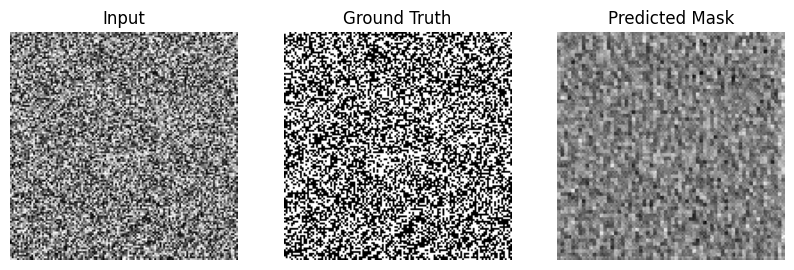

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

x_train = np.random.rand(100, 128, 128, 1)
y_train = (x_train > 0.5).astype(np.float32) # Binary masks
x_test = np.random.rand(10, 128, 128, 1)
y_test = (x_test > 0.5).astype(np.float32)

# CNN for Image Segmentation Ex 5
# Date:
inputs = layers.Input((128, 128, 1))
c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
p1 = layers.MaxPooling2D((2, 2))(c1)
c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
u1 = layers.UpSampling2D((2, 2))(c2)
concat1 = layers.concatenate([u1, c1])
outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(concat1)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3, batch_size=8, validation_split=0.1)

loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

sample = x_test[0]
pred_mask = model.predict(sample[np.newaxis, ...])[0, ..., 0]

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.title("Input")
plt.imshow(sample.squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(y_test[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')
plt.show()